## 월별 2020 데이터 합치고 성동구만 남기기

In [1]:
import pandas as pd


In [151]:
# 데이터 불러오기 
names = pd.read_csv("../Data/tpss_bcycl_od_statnhm_202412_merged.csv",encoding='utf-8',index_col=None)
names.head()



,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리
0,20241201,도착시간,1515,ST-3182,구로2동_001_6,ST-1976,문래동_032_1,1,16.0,2204.0
1,20241201,도착시간,1200,ST-547,잠실2동_058_1,ST-551,잠실3동_029_1,1,5.0,752.0
2,20241201,도착시간,1125,ST-1065,가양1동_016_2,ST-1688,가양1동_016_3,1,3.0,548.0
3,20241201,도착시간,1320,ST-2749,길동_012_1,ST-2749,길동_012_1,1,97.0,1216.0
4,20241201,도착시간,100,ST-3238,영등포동_056_1,ST-299,신길7동_009_1,1,18.0,2828.0


In [114]:
# 대여소 아이디 받아오기 
id= pd.read_csv("../Data/따릉이_성동구_대여소.csv",encoding='utf8')
id=id['대여소_ID']


In [152]:
#id가 포함된 내용만 Ture 표시 
names['대여소_포함'] = names['시작_대여소_ID'].isin(id) | names['종료_대여소_ID'].isin(id)

In [153]:
names[names['대여소_포함']==True]

,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_포함
35,20241201,도착시간,1750,ST-2342,용답동_019_1,ST-447,마장동_022_1,1,12.0,1006.0,True
61,20241201,도착시간,1450,ST-3003,성수2가3동_004_2,ST-3309,자양4동_013_1,1,7.0,1007.0,True
70,20241201,도착시간,1400,ST-243,용답동_004_1,ST-2787,행당1동_014_1,1,18.0,2938.0,True
104,20241201,도착시간,715,ST-2340,마장동_017_1,ST-408,용신동_007_2,1,8.0,1609.0,True
116,20241201,도착시간,2320,ST-2326,사근동_006_1,ST-243,용답동_004_1,1,20.0,2925.0,True
...,...,...,...,...,...,...,...,...,...,...,...
4239409,20241231,도착시간,1710,ST-364,성수2가3동_012_4,ST-105,성수2가3동_006_2,1,9.0,750.0,True
4239414,20241231,도착시간,1525,ST-3002,성수1가1동_009_1,ST-111,성수1가2동_019_1,1,2.0,550.0,True
4239415,20241231,도착시간,1740,ST-2341,성수1가1동_003_1,ST-107,성수1가1동_008_1,1,17.0,1542.0,True
4239478,20241231,도착시간,935,ST-3043,성수2가3동_012_1,ST-3003,성수2가3동_004_2,1,5.0,948.0,True


In [154]:
names = names[names['대여소_포함']]


In [155]:
names.columns

Index(['기준_날짜', '집계_기준', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '종료_대여소_ID',
       '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_포함'],
      dtype='object')

In [156]:
# 컬럼 사이 공백 지우기 
names.columns = names.columns.str.strip()

In [157]:



# 컬럼명 일괄 변경
names = names.rename(columns={
    '기준_날짜': '기준_날짜',
    '시작_대여소_ID': '시작_대여소ID',
    '종료_대여소_ID': '종료_대여소ID',
    '전체_이용_분': '전체이용시간(분)',
    '전체_이용_거리': '전체이용거리(m)'
})

# 변경된 컬럼으로 필요한 컬럼만 선택
names = names[['기준_날짜', '시작_대여소ID', '종료_대여소ID', '전체이용시간(분)', '전체이용거리(m)']]



In [158]:
names['대여'] = names['시작_대여소ID'].isin(id)
names['반납'] = names['종료_대여소ID'].isin(id)

In [159]:
names

,기준_날짜,시작_대여소ID,종료_대여소ID,전체이용시간(분),전체이용거리(m),대여,반납
35,20241201,ST-2342,ST-447,12.0,1006.0,True,True
61,20241201,ST-3003,ST-3309,7.0,1007.0,True,False
70,20241201,ST-243,ST-2787,18.0,2938.0,True,True
104,20241201,ST-2340,ST-408,8.0,1609.0,True,False
116,20241201,ST-2326,ST-243,20.0,2925.0,True,True
...,...,...,...,...,...,...,...
4239409,20241231,ST-364,ST-105,9.0,750.0,True,True
4239414,20241231,ST-3002,ST-111,2.0,550.0,True,True
4239415,20241231,ST-2341,ST-107,17.0,1542.0,True,True
4239478,20241231,ST-3043,ST-3003,5.0,948.0,True,True


In [160]:
names = names[
    ~(
        (names['전체이용시간(분)'] == 0) &
        (names['시작_대여소ID'] == names['종료_대여소ID']) &
        (names['전체이용거리(m)'] == 0.00)
    )
]


In [161]:
names

,기준_날짜,시작_대여소ID,종료_대여소ID,전체이용시간(분),전체이용거리(m),대여,반납
35,20241201,ST-2342,ST-447,12.0,1006.0,True,True
61,20241201,ST-3003,ST-3309,7.0,1007.0,True,False
70,20241201,ST-243,ST-2787,18.0,2938.0,True,True
104,20241201,ST-2340,ST-408,8.0,1609.0,True,False
116,20241201,ST-2326,ST-243,20.0,2925.0,True,True
...,...,...,...,...,...,...,...
4239409,20241231,ST-364,ST-105,9.0,750.0,True,True
4239414,20241231,ST-3002,ST-111,2.0,550.0,True,True
4239415,20241231,ST-2341,ST-107,17.0,1542.0,True,True
4239478,20241231,ST-3043,ST-3003,5.0,948.0,True,True


In [ ]:
names.to_csv("../Data/따릉이_2024_12.csv", index=False, encoding='utf-8-sig')

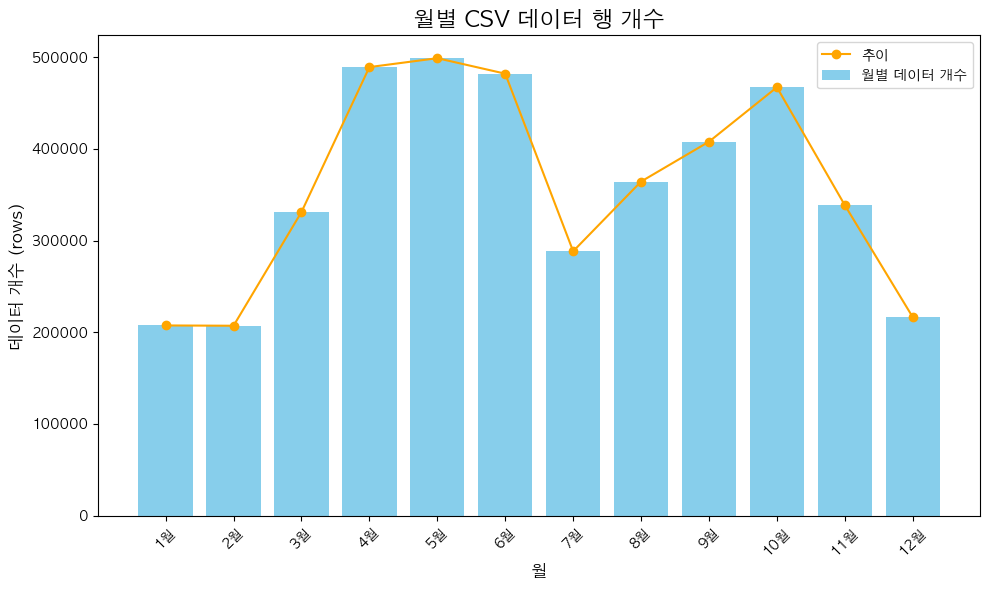

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os

# 한글 폰트 설정 (Mac 기준)
matplotlib.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 파일 리스트
csv_files = [
    '../Data/따릉이_2024_1.csv', '../Data/따릉이_2024_2.csv', '../Data/따릉이_2024_3.csv', '../Data/따릉이_2024_4.csv',
    '../Data/따릉이_2024_5.csv', '../Data/따릉이_2024_6.csv', '../Data/따릉이_2024_7.csv', '../Data/따릉이_2024_8.csv',
    '../Data/따릉이_2024_9.csv', '../Data/따릉이_2024_10.csv', '../Data/따릉이_2024_11.csv', '../Data/따릉이_2024_12.csv'
]

month_counts = []

for file in csv_files:
    try:
        df = pd.read_csv(file, encoding='cp949')
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(file, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(file, encoding='utf-8-sig')
    except FileNotFoundError:
        print(f"❌ 파일 없음: {file}")
        month_counts.append(0)
        continue

    month_counts.append(len(df))

# 월 레이블
months = [f"{i}월" for i in range(1, 13)]

# 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(months, month_counts, color='skyblue', label='월별 데이터 개수')
plt.plot(months, month_counts, color='orange', marker='o', linestyle='-', label='추이')

plt.title('월별 CSV 데이터 행 개수', fontsize=16)
plt.xlabel('월', fontsize=12)
plt.ylabel('데이터 개수 (rows)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

월
1    2797123
Name: count, dtype: int64
